In [ ]:
#BGE sample
from FlagEmbedding import FlagModel

model = FlagModel(
    'BAAI/bge-large-zh-v1.5',
    query_instruction_for_retrieval="为这个句子生成表示以用于检索：",
    use_fp16=True
)

sentences_1 = ["我爱自然语言处理", "我喜欢机器学习"]
sentences_2 = ["我热爱BGE模型", "我关注文本检索"]

embeddings_1 = model.encode(sentences_1)
embeddings_2 = model.encode(sentences_2)

import numpy as np
similarity = np.matmul(embeddings_1, embeddings_2.T)
print(similarity)


/usr/local/miniconda3/envs/AIaplication_pro/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


[[0.4207 0.4873]
 [0.519  0.562 ]]


In [ ]:
#统一处理数据
import os, json, random
from glob import glob

random.seed(42)

DATA_DIR = "CSTS"
OUT_DIR = "CSTS_BGE"
os.makedirs(OUT_DIR, exist_ok=True)

def read_txt_file(path):
    """读取 CSTS 的 txt 文件，返回 [(s1, s2, label), ...]"""
    pairs = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 3:
                continue
            s1, s2, label = parts[0].strip(), parts[1].strip(), parts[2].strip()
            if not s1 or not s2:
                continue
            label = label.strip().lower()
            if label in ['1', '1.0', 'true', 't']:
                lab = 1
            elif label in ['0', '0.0', 'false', 'f']:
                lab = 0
            else:
                try:
                    lab = int(float(label) > 0.5)
                except:
                    continue
            pairs.append((s1, s2, lab))
    return pairs


def build_jsonl(split='train'):
    """整合 AFQMC, LCQMC, OPPO-xiaobu 三个子集生成统一 JSONL"""
    all_samples = []
    for sub in ['AFQMC', 'LCQMC', 'OPPO-xiaobu']:
        path = os.path.join(DATA_DIR, sub, f'{split}.txt')
        if not os.path.exists(path):
            print(f"⚠️ {path} 不存在，跳过")
            continue
        data = read_txt_file(path)
        all_samples.extend(data)
        print(f"✅ 读取 {sub}/{split}.txt: {len(data)} 条")

    print(f"➡️ 合并后 {split} 样本总数：{len(all_samples)}")
    
    output_path = os.path.join(OUT_DIR, f'{split}.jsonl')
    with open(output_path, 'w', encoding='utf-8') as f:
        for i, (s1, s2, lab) in enumerate(all_samples):
            f.write(json.dumps({
                        "sentence1": s1,
                        "sentence2": s2,
                        "label": lab
                    }, ensure_ascii=False) + '\n')


    print(f"✅ 已保存 {output_path}")
    print("—"*30)

# === 执行 ===
build_jsonl('train')
build_jsonl('dev')


✅ 读取 AFQMC/train.txt: 34334 条
✅ 读取 LCQMC/train.txt: 238766 条
✅ 读取 OPPO-xiaobu/train.txt: 167168 条
➡️ 合并后 train 样本总数：440268
✅ 已保存 CSTS_BGE/train.jsonl
——————————————————————————————
✅ 读取 AFQMC/dev.txt: 4316 条
✅ 读取 LCQMC/dev.txt: 8802 条
✅ 读取 OPPO-xiaobu/dev.txt: 10000 条
➡️ 合并后 dev 样本总数：23118
✅ 已保存 CSTS_BGE/dev.jsonl
——————————————————————————————


In [ ]:
#生成train的相似度分数
from sentence_transformers import SentenceTransformer
import json, numpy as np, os
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

def generate_bge_scores(model_path, input_file, output_file, batch_size=32):
    # 加载模型
    print(f"🔹 加载模型: {model_path}")
    model = SentenceTransformer(model_path)

    # 读取句对
    pairs = []
    with open(input_file, "r", encoding="utf-8") as f:
        for line in f:
            d = json.loads(line)
            pairs.append((d["sentence1"], d["sentence2"], int(d["label"])))

    # 编码并计算相似度
    sents1 = [p[0] for p in pairs]
    sents2 = [p[1] for p in pairs]
    labels = [p[2] for p in pairs]

    emb1 = model.encode(sents1, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=True)
    emb2 = model.encode(sents2, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=True)
    sims = np.sum(emb1 * emb2, axis=1)

    # 保存结果
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, "w", encoding="utf-8") as f:
        for s, l in zip(sims, labels):
            f.write(json.dumps({"score": float(s), "label": int(l)}, ensure_ascii=False) + "\n")
    print(f"✅ 已生成相似度文件: {output_file}")


generate_bge_scores(
    model_path="./bge-base-zh-v1.5-csts-finetuned",
    input_file="CSTS_BGE/train.jsonl",
    output_file="CSTS_BGE/train_score.jsonl"
)


🔹 加载模型: ./bge-base-zh-v1.5-csts-finetuned


Batches: 100%|██████████| 13759/13759 [02:16<00:00, 100.62it/s]


✅ 已生成相似度文件: CSTS_BGE/score.jsonl


✅ [训练集] 最佳阈值 θ* = 0.570, 对应 F1 = 0.9394
📈 阈值–F1 曲线已保存: CSTS_BGE/threshold_curve_train.png


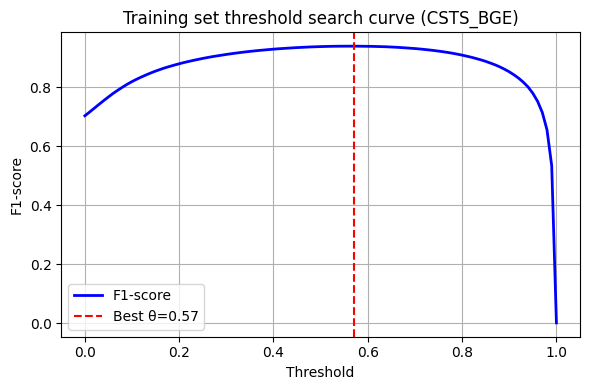


部分阈值结果示例：
θ=0.00 | Acc=0.615 | Prec=0.543 | Rec=1.000 | F1=0.703
θ=0.10 | Acc=0.799 | Prec=0.695 | Rec=0.998 | F1=0.819
θ=0.20 | Acc=0.876 | Prec=0.789 | Rec=0.994 | F1=0.880
θ=0.30 | Acc=0.912 | Prec=0.847 | Rec=0.986 | F1=0.911
θ=0.40 | Acc=0.932 | Prec=0.886 | Rec=0.977 | F1=0.929
θ=0.50 | Acc=0.942 | Prec=0.915 | Rec=0.963 | F1=0.938
θ=0.60 | Acc=0.944 | Prec=0.936 | Rec=0.942 | F1=0.939
θ=0.70 | Acc=0.939 | Prec=0.953 | Rec=0.910 | F1=0.931
θ=0.80 | Acc=0.922 | Prec=0.967 | Rec=0.857 | F1=0.909
θ=0.90 | Acc=0.881 | Prec=0.980 | Rec=0.754 | F1=0.853
θ=1.00 | Acc=0.544 | Prec=0.981 | Rec=0.001 | F1=0.002


In [ ]:
#寻找阈值
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 默认字体
matplotlib.rcParams['axes.unicode_minus'] = False          # 允许负号


def load_scores_labels(path):
    scores, labels = [], []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            d = json.loads(line)
            scores.append(float(d["score"]))
            labels.append(int(d["label"]))
    return np.array(scores), np.array(labels)




# 在训练集上搜索最佳阈值
def find_best_threshold(
    scores,
    labels,
    step=0.01,
    plot_path="CSTS_BGE/threshold_curve_train.png",
    show_plot=False
):
    thresholds = np.arange(0.0, 1.0 + step, step)
    best_th, best_f1 = 0, 0
    metrics = []

    for th in thresholds:
        preds = (scores >= th).astype(int)
        acc = accuracy_score(labels, preds)
        pre = precision_score(labels, preds, zero_division=0)
        rec = recall_score(labels, preds, zero_division=0)
        f1 = f1_score(labels, preds, zero_division=0)
        metrics.append((th, acc, pre, rec, f1))
        if f1 > best_f1:
            best_f1, best_th = f1, th

    print(f"✅ [训练集] 最佳阈值 θ* = {best_th:.3f}, 对应 F1 = {best_f1:.4f}")

    # 绘制曲线
    ths = [m[0] for m in metrics]
    f1s = [m[4] for m in metrics]
    plt.figure(figsize=(6, 4))
    plt.plot(ths, f1s, color="blue", linewidth=2, label="F1-score")
    plt.axvline(best_th, color="red", linestyle="--", label=f"Best θ={best_th:.2f}")
    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title("Training set threshold search curve (CSTS_BGE)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # 保存图片
    plt.savefig(plot_path, dpi=200)
    print(f"📈 阈值–F1 曲线已保存: {plot_path}")

    # 展示图像
    if show_plot:
        from IPython.display import display
        display(plt.gcf()) 

    plt.close()
    return best_th, metrics



if __name__ == "__main__":
    score_file = "CSTS_BGE/train_score.jsonl"
    scores, labels = load_scores_labels(score_file)
    best_th, metrics = find_best_threshold(scores, labels, step=0.01, show_plot=True)

    print("\n部分阈值结果示例：")
    for th, acc, pre, rec, f1 in metrics[::10]:
        print(f"θ={th:.2f} | Acc={acc:.3f} | Prec={pre:.3f} | Rec={rec:.3f} | F1={f1:.3f}")


In [17]:
#生成dev_score.jsonl
from sentence_transformers import SentenceTransformer
import json, numpy as np, os
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

def generate_bge_scores(model_path, input_file, output_file, batch_size=32):
    # 1. 加载模型
    print(f"🔹 加载模型: {model_path}")
    model = SentenceTransformer(model_path)

    # 2. 读取句对
    pairs = []
    with open(input_file, "r", encoding="utf-8") as f:
        for line in f:
            d = json.loads(line)
            pairs.append((d["sentence1"], d["sentence2"], int(d["label"])))

    # 3. 编码并计算相似度
    sents1 = [p[0] for p in pairs]
    sents2 = [p[1] for p in pairs]
    labels = [p[2] for p in pairs]

    emb1 = model.encode(sents1, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=True)
    emb2 = model.encode(sents2, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=True)
    sims = np.sum(emb1 * emb2, axis=1)

    # 4. 保存结果
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, "w", encoding="utf-8") as f:
        for s, l in zip(sims, labels):
            f.write(json.dumps({"score": float(s), "label": int(l)}, ensure_ascii=False) + "\n")
    print(f"✅ 已生成相似度文件: {output_file}")

# === 调用示例 ===
generate_bge_scores(
    model_path="./bge-base-zh-v1.5-csts-finetuned",
    input_file="CSTS_BGE/dev.jsonl",
    output_file="CSTS_BGE/dev_score.jsonl"
)


🔹 加载模型: ./bge-base-zh-v1.5-csts-finetuned


Batches: 100%|██████████| 723/723 [00:07<00:00, 101.26it/s]


✅ 已生成相似度文件: CSTS_BGE/dev_score.jsonl


In [ ]:
#评估BGE模型的性能
import json
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from scipy.stats import spearmanr, pearsonr

def load_scores_labels(path):
    scores, labels = [], []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            d = json.loads(line)
            scores.append(float(d["score"]))
            labels.append(int(d["label"]))
    return np.array(scores), np.array(labels)

def evaluate_dev(scores, labels, threshold=0.57):
    preds = (scores >= threshold).astype(int)

    acc = accuracy_score(labels, preds)
    pre = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, scores)
    rho, _ = spearmanr(scores, labels)
    r, _ = pearsonr(scores, labels)

    print(f"📊 [验证集评估结果] (θ = {threshold:.2f})")
    print(f"Accuracy = {acc:.4f}")
    print(f"Precision = {pre:.4f}")
    print(f"Recall = {rec:.4f}")
    print(f"F1-score = {f1:.4f}")
    print(f"AUC = {auc:.4f}")
    print(f"Spearman = {rho:.4f}")
    print(f"Pearson = {r:.4f}")

    return {
        "Accuracy": acc, "Precision": pre, "Recall": rec, "F1": f1,
        "AUC": auc, "Spearman": rho, "Pearson": r
    }


if __name__ == "__main__":
    dev_file = "CSTS_BGE/dev_score.jsonl"  
    scores, labels = load_scores_labels(dev_file)
    evaluate_dev(scores, labels, threshold=0.57)


📊 [验证集评估结果] (θ = 0.57)
Accuracy = 0.8363
Precision = 0.7715
Recall = 0.8082
F1-score = 0.7895
AUC = 0.9111
Spearman = 0.6911
Pearson = 0.7082
